In [18]:
import numpy as np
import torch
from torch_geometric.data import Data
from e3nn import o3
torch.set_default_dtype(torch.float64)
from src.E3Model import Network
import torch_cluster
import matplotlib.pyplot as plt
import e3nn as e3nn

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
 

def build_graph_inputs(data, irreps_sh, radius=3.0, num_radial=16):

    pos = data.pos
    batch = data.batch

    edge_index = torch_cluster.radius_graph(pos, r=radius, batch=batch)
    src, dst = edge_index

    edge_vec = pos[dst] - pos[src]
    edge_len = edge_vec.norm(dim=1)

    edge_sh = o3.spherical_harmonics(
        irreps_sh, edge_vec, normalize=True, normalization="component"
    )

    edge_length_emb = e3nn.math.soft_one_hot_linspace(
        edge_len,
        start=0.0,
        end=radius,
        number=num_radial,
        basis="smooth_finite",
        cutoff=True,
    ).mul(num_radial**0.5)

    node_input = data.x[:, :5]

    return {
        "node_input": node_input,
        "edge_index": edge_index,
        "edge_sh": edge_sh,
        "edge_length_emb": edge_length_emb,
        "batch": batch,
    }


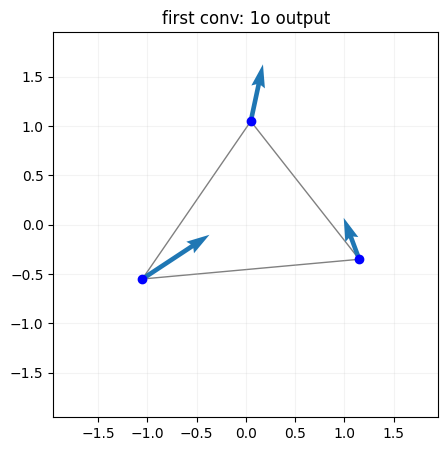

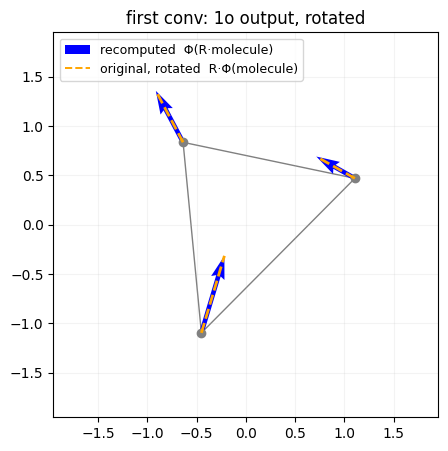

In [46]:
seed = 37
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

pos = torch.tensor([[-1.05, -0.55, 0.0],
                    [ 1.15, -0.35, 0.0],
                    [ 0.05,  1.05, 0.0]])
x = torch.zeros(3, 11); x[range(3), [1, 3, 2]] = 1.0          
data = Data(pos=pos, x=x, batch=torch.zeros(3, dtype=torch.long))
 
conv = Network().eval().convs[0]

IRREPS_SH = o3.Irreps.spherical_harmonics(1)
def vectors(data):
    g = build_graph_inputs(data, irreps_sh=IRREPS_SH, radius=4.5, num_radial=16)
    src, dst = g["edge_index"]
    out = conv(g["node_input"], src, dst, g["edge_sh"], g["edge_length_emb"])
    return out[:, 60:].reshape(-1, 20, 3)[:, 0]              
 
th = np.deg2rad(40)     # rotation matrix                                    
c, s = np.cos(th), np.sin(th)
R = torch.tensor([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=torch.float64)
 

data_rot = data.clone()
data_rot.pos = data.pos @ R.T
 
v1 = vectors(data).detach().numpy() # original pass through
v2 = vectors(data_rot).detach().numpy() # rotated pass through
v1, v2 = v1 * 1.5, v2 * 1.5 # rescaler vectorerne så de nemmere for plot
v1R = v1 @ R.numpy().T                                       
p1, p2 = data.pos.numpy(), data_rot.pos.detach().numpy()     
 

bonds = [(0, 1), (1, 2), (2, 0)]
lim = 1.2 * np.abs(np.vstack([p1[:, :2], p1[:, :2] + v1[:, :2],
                              p2[:, :2], p2[:, :2] + v2[:, :2]])).max()
q = dict(angles="xy", scale_units="xy", scale=1)           
 
def frame(title):
    plt.gca().set_aspect("equal"); plt.xlim(-lim, lim); plt.ylim(-lim, lim)
    plt.grid(alpha=0.15); plt.title(title)
 
def bondlines(P):
    for i, j in bonds:
        plt.plot([P[i, 0], P[j, 0]], [P[i, 1], P[j, 1]], color="gray", lw=1, zorder=0)
 
# figure 1
plt.figure(figsize=(5, 5)); bondlines(p1)
plt.scatter(p1[:, 0], p1[:, 1], color="blue", zorder=3)
plt.quiver(p1[:, 0], p1[:, 1], v1[:, 0], v1[:, 1], color="C0", width=0.012, zorder=2, **q)
frame("first conv: 1o output")
plt.show()
 
# figur 2
plt.figure(figsize=(5, 5)); bondlines(p2)
plt.scatter(p2[:, 0], p2[:, 1], color="gray", zorder=3)
plt.quiver(p2[:, 0], p2[:, 1], v2[:, 0], v2[:, 1], color="blue", width=0.012, zorder=2,
           label="recomputed  Φ(R·molecule)", **q)
for (xx, yy), (u, w) in zip(p2[:, :2], v1R[:, :2]):
    plt.plot([xx, xx + u], [yy, yy + w], color="Orange", ls="--", lw=2, zorder=4)
plt.plot([], [], color="orange", ls="--", lw=1.4, label="original, rotated  R·Φ(molecule)")
plt.legend(loc="upper left", fontsize=9)
frame("first conv: 1o output, rotated")
plt.show()

In [58]:
v1R-v2

array([[-2.77555756e-16, -2.55351296e-15,  0.00000000e+00],
       [-7.77156117e-16, -9.43689571e-16,  0.00000000e+00],
       [ 2.77555756e-16, -2.66453526e-15,  0.00000000e+00]])

gap before rotation: -0.008402037693363305
gap after rotation:  -0.008402037693363378
difference:          7.28583859910259e-17


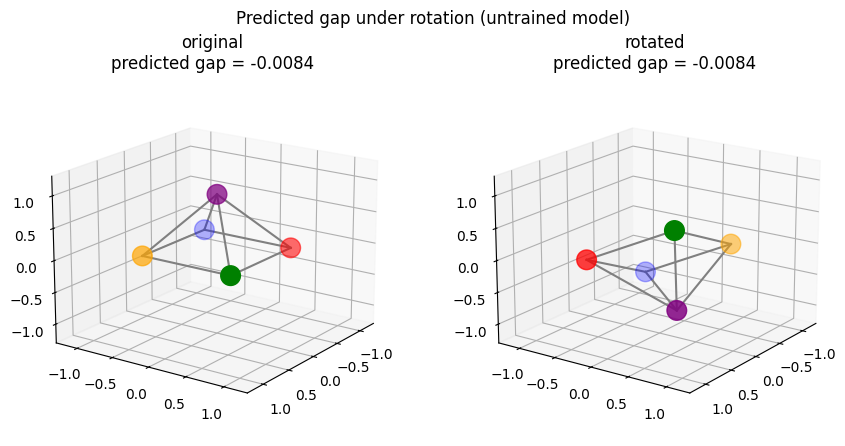

In [65]:
torch.manual_seed(28)
a = 0.6
h = 0.9
pos = torch.tensor([[-a, -a, 0.0],[a, -a, 0.0],[a, a, 0.0],[-a, a, 0.0],[0.0, 0.0, h]])
x = torch.zeros(5, 11)
for i in range(5):
   x[i, i] = 1
z = torch.tensor([1, 6, 7, 8, 9])  
batch = torch.zeros(5, dtype=torch.long)
data = Data(pos=pos, x=x, z=z, batch=batch)
model = Network().double().eval()

@torch.no_grad()
def predict_gap(model, data):
    return float(model(data).reshape(-1)[0])

gap_base = predict_gap(model, data)
 
# rotate the pyramid and predict again
R = o3.rand_matrix()
data_rot = data.clone()
data_rot.pos = data.pos @ R.T
gap_rot = predict_gap(model, data_rot)

print("gap before rotation:", gap_base)
print("gap after rotation: ", gap_rot)
print("difference:         ", abs(gap_rot - gap_base))
 

edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 4), (1, 4), (2, 4), (3, 4)]
colors = ["blue", "orange", "green", "red", "purple"]
 
 
def draw(ax, pos, gap, title):
    pos = pos.numpy()
    for i, j in edges:
        ax.plot([pos[i, 0], pos[j, 0]],
                [pos[i, 1], pos[j, 1]],
                [pos[i, 2], pos[j, 2]], color="gray")
    ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], c=colors, s=200)
    ax.set_title(title + "\npredicted gap = %.4f" % gap)
    ax.view_init(elev=18, azim=35)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_zlim(-1.3, 1.3)
 
 
fig = plt.figure(figsize=(9, 4.5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
draw(ax1, data.pos, gap_base, "original")
draw(ax2, data_rot.pos, gap_rot, "rotated")
 
fig.suptitle("Predicted gap under rotation (untrained model)")
fig.tight_layout()

In [64]:
R.det(),R

(tensor(1.0000),
 tensor([[ 0.4226, -0.8445,  0.3288],
         [ 0.4413, -0.1251, -0.8886],
         [ 0.7916,  0.5207,  0.3198]]))

In [67]:
for i in range(50):
    R = o3.rand_matrix()
    print(R.det())

tensor(1.0000)
tensor(1.0000)
tensor(1.0000)
tensor(1.)
tensor(1.)
tensor(1.0000)
tensor(1.0000)
tensor(1.)
tensor(1.0000)
tensor(1.0000)
tensor(1.)
tensor(1.0000)
tensor(1.)
tensor(1.0000)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.0000)
tensor(1.0000)
tensor(1.0000)
tensor(1.0000)
tensor(1.0000)
tensor(1.0000)
tensor(1.0000)
tensor(1.)
tensor(1.0000)
tensor(1.)
tensor(1.0000)
tensor(1.0000)
tensor(1.)
tensor(1.0000)
tensor(1.0000)
tensor(1.0000)
tensor(1.0000)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.)
tensor(1.0000)
tensor(1.0000)
tensor(1.0000)
tensor(1.)
tensor(1.0000)
tensor(1.)
tensor(1.0000)
tensor(1.)
tensor(1.0000)
tensor(1.0000)
tensor(1.0000)
tensor(1.)
